<a href="https://colab.research.google.com/github/AnkushKargal/ppi-viral-pathogen-prediction/blob/main/ppi_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandansureja/ppi-dataset")

print("Path to dataset files:", path)

100%|██████████| 47.7M/47.7M [00:00<00:00, 208MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spandansureja/ppi-dataset/versions/1


In [2]:
import os

print(os.listdir(path))

['positive_protein_sequences.csv', 'negative_protein_sequences.csv']


In [3]:
import pandas as pd
import os

files = os.listdir(path)

print(files)

['positive_protein_sequences.csv', 'negative_protein_sequences.csv']


In [4]:
file_name = files[0]

df = pd.read_csv(
    os.path.join(path, file_name)
)

print(df.shape)

df.head()

(36630, 2)


,protein_sequences_1,protein_sequences_2
0,MESSKKMDSPGALQTNPPLKLHTDRSAGTPVFVPEQGGYKEKFVKT...,MARPHPWWLCVLGTLVGLSATPAPKSCPERHYWAQGKLCCQMCEPG...
1,MVMSSYMVNSKYVDPKFPPCEEYLQGGYLGEQGADYYGGGAQGADF...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
2,MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...,MEGGRRARVVIESKRNFFLGAFPTPFPAEHVELGRLGDSETAMVPG...
3,MAPPSTREPRVLSATSATKSDGEMVLPGFPDADSFVKFALGSVVAV...,MLFYSFFKSLVGKDVVVELKNDLSICGTLHSVDQYLNIKLTDISVT...
4,MQSGPRPPLPAPGLALALTLTMLARLASAASFFGENHLEVPVATAL...,MQTIKCVVVGDGAVGKTCLLISYTTNKFPSEYVPTVFDNYAVTVMI...


In [6]:
print(df.columns)

Index(['protein_sequences_1', 'protein_sequences_2'], dtype='object')


In [7]:
df["combined_seq"] = (
    df["protein_sequences_1"] +
    " " +
    df["protein_sequences_2"]
)

df["label"] = [1 if i < len(df)/2 else 0 for i in range(len(df))]

print(df.head())

print(df["label"].value_counts())

                                 protein_sequences_1  \
0  MESSKKMDSPGALQTNPPLKLHTDRSAGTPVFVPEQGGYKEKFVKT...   
1  MVMSSYMVNSKYVDPKFPPCEEYLQGGYLGEQGADYYGGGAQGADF...   
2  MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...   
3  MAPPSTREPRVLSATSATKSDGEMVLPGFPDADSFVKFALGSVVAV...   
4  MQSGPRPPLPAPGLALALTLTMLARLASAASFFGENHLEVPVATAL...   

                                 protein_sequences_2  \
0  MARPHPWWLCVLGTLVGLSATPAPKSCPERHYWAQGKLCCQMCEPG...   
1  MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...   
2  MEGGRRARVVIESKRNFFLGAFPTPFPAEHVELGRLGDSETAMVPG...   
3  MLFYSFFKSLVGKDVVVELKNDLSICGTLHSVDQYLNIKLTDISVT...   
4  MQTIKCVVVGDGAVGKTCLLISYTTNKFPSEYVPTVFDNYAVTVMI...   

                                        combined_seq  label  
0  MESSKKMDSPGALQTNPPLKLHTDRSAGTPVFVPEQGGYKEKFVKT...      1  
1  MVMSSYMVNSKYVDPKFPPCEEYLQGGYLGEQGADYYGGGAQGADF...      1  
2  MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...      1  
3  MAPPSTREPRVLSATSATKSDGEMVLPGFPDADSFVKFALGSVVAV...      1  
4  MQSGPRPPLPAPG

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,3)
)

X = vectorizer.fit_transform(df["combined_seq"])

y = df["label"]

print(X.shape)

(36630, 8446)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(29304, 8446)
(7326, 8446)


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

predictions = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Accuracy: 0.4987714987714988
Precision: 0.4948852640309649
Recall: 0.4924346629986245
F1 Score: 0.4936569222283508


In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

print("SVM Training Complete")

SVM Training Complete


In [14]:
predictions = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Accuracy: 0.5032760032760033
Precision: 0.4994591671173607
Recall: 0.5081155433287483
F1 Score: 0.5037501704622938


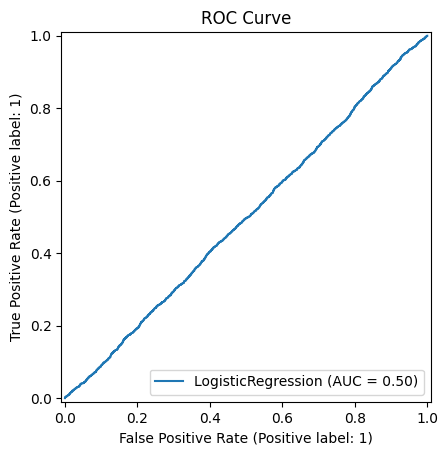

In [15]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

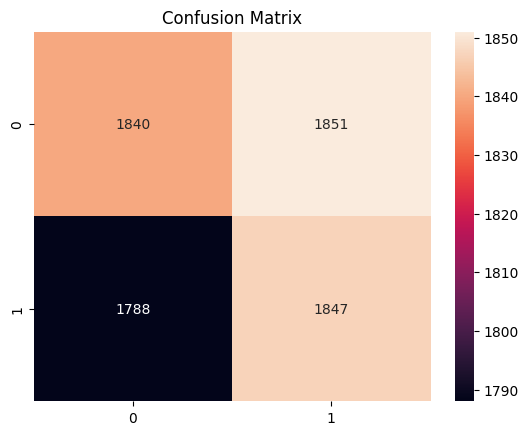

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [17]:
!pip install tensorflow

In [18]:
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

from sklearn.model_selection import train_test_split

In [20]:
texts = df["combined_seq"].astype(str)

labels = df["label"]

In [21]:
tokenizer = Tokenizer(char_level=True)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

In [22]:
max_length = 500

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

y = np.array(labels)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = Sequential()

model.add(
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=32,
        input_length=max_length
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dense(1, activation='sigmoid')
)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/3
825/825 ━━━━━━━━━━━━━━━━━━━━ 230s 270ms/step - accuracy: 0.4964 - loss: 0.6933 - val_accuracy: 0.5056 - val_loss: 0.6935
Epoch 2/3
825/825 ━━━━━━━━━━━━━━━━━━━━ 226s 274ms/step - accuracy: 0.5027 - loss: 0.6932 - val_accuracy: 0.4927 - val_loss: 0.6941
Epoch 3/3
825/825 ━━━━━━━━━━━━━━━━━━━━ 228s 277ms/step - accuracy: 0.5103 - loss: 0.6929 - val_accuracy: 0.4923 - val_loss: 0.6942


In [26]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

229/229 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4967 - loss: 0.6937
Test Accuracy: 0.496724009513855


In [27]:
predictions = model.predict(X_test)

print(predictions[:5])

229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step
[[0.51545167]
 [0.50570583]
 [0.46336114]
 [0.51514506]
 [0.48485965]]


In [28]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 137ms/step - accuracy: 0.4967 - loss: 0.6937
Test Accuracy: 0.496724009513855


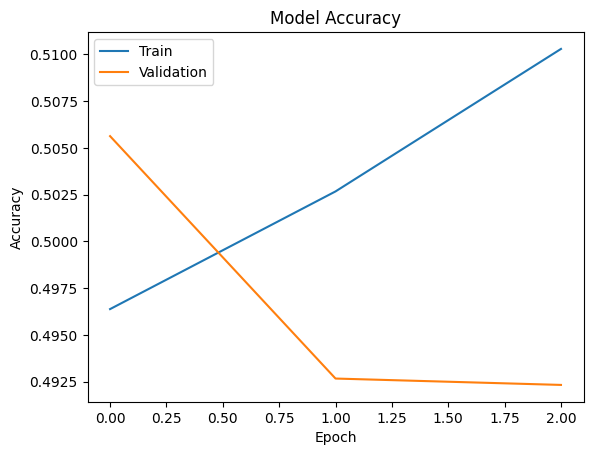

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

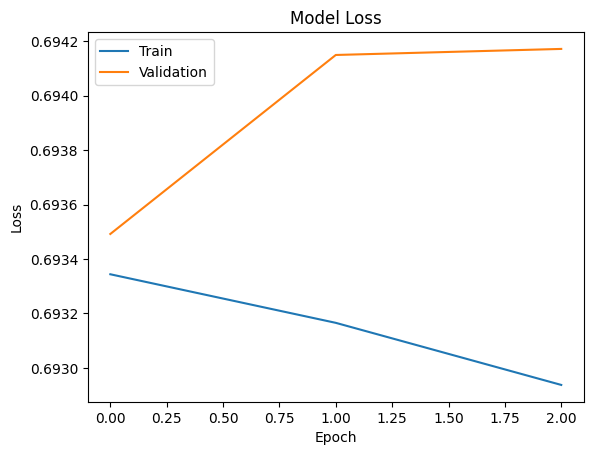

In [30]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [31]:
model.save("ppi_lstm_model.h5")

In [32]:
model.save("ppi_lstm_model.keras")

In [33]:
from google.colab import files

files.download("ppi_lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>